# Mini Projet : Data Process et Data Visualization

**Traitement de données avec Python** 

---

### Objectif

Ce projet combine deux compétences vues en cours :
- **Phase A (Data Process)** : import, nettoyage, filtrage et extraction de données avec Pandas (séquences 1 à 7 et 12).
- **Phase B (Data Visualization)** : transformer un résultat de la Phase A en une communication explicative claire, en appliquant les principes du cours (contexte Who/What/How, choix du graphique, élimination du clutter).

### Données

Source ouverte et accessible : [OurAirports](https://ourairports.com/data/), base mondiale des aéroports, mise à jour quotidiennement.


---
# Identification et individualisation des paramètres

Le sous-ensemble de pays et le scénario de communication , déterminés automatiquement à partir de mon matricule. 


In [28]:
import hashlib

MATRICULE = "N00401020211"  # matricule 

REGIONS = {
    0: ("Afrique de l'Ouest", ["BF", "ML", "NE", "SN", "CI", "GH", "NG", "TG", "BJ", "GN"]),
    1: ("Afrique de l'Est", ["KE", "TZ", "UG", "ET", "RW", "SO", "DJ", "BI"]),
    2: ("Afrique australe", ["ZA", "ZW", "ZM", "BW", "NA", "MZ", "MW"]),
    3: ("Amérique centrale", ["GT", "HN", "SV", "NI", "CR", "PA", "BZ"]),
    4: ("Asie du Sud-Est", ["TH", "VN", "KH", "LA", "MM", "PH", "ID", "MY"]),
    5: ("Europe de l'Est", ["PL", "CZ", "SK", "HU", "RO", "BG", "UA"]),
}

SCENARIOS = {
    0: ("A", "Comité d'investissement régional",
        "Justification d'un investissement dans un pays sous-desservi de mon échantillon"),
    1: ("B", "Grand public, via un article de blog",
        "Sensibilisation sur les inégalités d'accès au transport aérien dans  l'échantillon"),
    2: ("C", "Compagnie aérienne low-cost",
        "Identification d'une opportunité de marché : un pays sans grand aéroport actif"),
}

seed = int(hashlib.sha256(MATRICULE.encode()).hexdigest(), 16)
region_id = seed % len(REGIONS)
scenario_id = (seed // len(REGIONS)) % len(SCENARIOS)

region_name, region_countries = REGIONS[region_id]
scenario_code, scenario_who, scenario_what = SCENARIOS[scenario_id]

print(f"Région assignée   : {region_name} {region_countries}")
print(f"Scénario assigné  : {scenario_code}")
print(f"  Who (audience)  : {scenario_who}")
print(f"  What (message)  : {scenario_what}")


Région assignée   : Afrique australe ['ZA', 'ZW', 'ZM', 'BW', 'NA', 'MZ', 'MW']
Scénario assigné  : A
  Who (audience)  : Comité d'investissement régional
  What (message)  : Justification d'un investissement dans un pays sous-desservi de mon échantillon


---
# PHASE A : Data Process

## 1- Importation des données


In [29]:
import pandas as pd

URL = "https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/airports.csv"

df = pd.read_csv(URL, keep_default_na=False, na_values=[""])
print(df.shape)
df.head()


(85616, 19)


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NA,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NA,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NA,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NA,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NA,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN



##### On désactive la détection automatique des NaN de pandas et on ne déclare que la chaîne vide comme valeur manquante. car,par défaut, pandas interprète la chaîne "NA" comme une valeur manquante. Or "NA" est aussi le code ISO du pays Namibie ! Sans cette précaution, les 303 aéroports namibiens seraient silencieusement perdus .

## 2- Prétraitement

In [30]:
# Ne garder que les colonnes utiles
df = df[["ident", "name", "type", "iso_country", "latitude_deg", "longitude_deg",
         "elevation_ft", "scheduled_service"]]

# Renommer ces colonnes
df = df.rename(columns={
    "ident": "ID",
    "name": "airport_name",
    "type": "type",
    "iso_country": "country",
    "latitude_deg": "lat",
    "longitude_deg": "long",
    "elevation_ft": "elevation",
    "scheduled_service": "service",
})

# 'elevation' a été lue comme texte à cause de keep_default_na=False : on la repasse en numérique.
# errors="coerce" transforme en NaN les éventuelles valeurs non numériques restantes.
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce")

df.head()


,ID,airport_name,type,country,lat,long,elevation,service
0,00A,Total RF Heliport,heliport,US,40.070985,-74.933689,11.0,no
1,00AA,Aero B Ranch Airport,small_airport,US,38.704022,-101.473911,3435.0,no
2,00AK,Lowell Field,small_airport,US,59.947733,-151.692524,450.0,no
3,00AL,Epps Airpark,small_airport,US,34.864799,-86.770302,820.0,no
4,00AN,Katmai Lodge Airport,small_airport,US,59.093287,-156.456699,80.0,no


### Traitement des valeurs manquantes

Le dataset contient des valeurs manquantes dans *elevation*.nous passerons a leurs traitements

In [4]:
# valeurs manquantes dans 'elevation' 
nb_nan = df["elevation"].isnull().sum()
print(f"Valeurs manquantes dans 'elevation' : {nb_nan} sur {len(df)} lignes "
      f"({nb_nan / len(df):.1%})")

print(df["elevation"].describe())


Valeurs manquantes dans 'elevation' : 14852 sur 85616 lignes (17.3%)
count    70764.000000
mean      1292.497470
std       1657.003804
min      -1266.000000
25%        208.000000
50%        728.000000
75%       1608.000000
max      17372.000000
Name: elevation, dtype: float64


**Justification de la stratégie choisie :** CONSERVATION des NaN (pas de suppression de lignes, pas d'imputation).
 'elevation' n'est utilisée dans la suite du projet que pour des opérations de tri/extrême sur la région assignée, jamais comme variable structurante de la synthèse par pays. 
- Imputer fausserait ces extrêmes 
- supprimer les lignes ferait perdre des aéroports par ailleurs valides (nom, pays, statut de service) juste parce que leur altitude n'est pas renseignée dans la source. 
- On laisse donc les NaN tels quels : pandas les ignore nativement dans nsmallest/nlargest et dans les agrégations par pays.


In [31]:
df.to_csv("airports_clean.csv", index=False)
print("Fichier 'airports_clean.csv' sauvegardé :", df.shape)


Fichier 'airports_clean.csv' sauvegardé : (85616, 8)


## 3- Opérations individualisées

Toutes les opérations suivantes portent uniquement sur la région qui a été assignée ci-dessus.


In [32]:
# Filtrage du DataFrame sur les pays de la région assignée
df_region = df[df["country"].isin(region_countries)].copy()

print(f"Nombre d'aéroports dans la région {region_name} : {len(df_region)}")
df_region.head()


Nombre d'aéroports dans la région Afrique australe : 1552


,ID,airport_name,type,country,lat,long,elevation,service
10079,AME,Alto Molocue Airport,small_airport,MZ,-15.610278,37.681389,1950.0,no
12572,BCW,Benguera Island Airport,medium_airport,MZ,-21.853300,35.438301,NaN,no
16426,BW-0001,Khuis Airport,small_airport,BW,-26.649130,21.822150,3071.0,no
16427,BW-0002,Motopi Airport,small_airport,BW,-20.185886,24.175029,3070.0,no
16428,BW-0003,Seronga Airport,small_airport,BW,-18.823303,22.422619,3240.0,no


In [33]:
# Extraction les aéroports dont le nom contient un mo-clé  ("International")
mot_cle = "International"
international = df_region[df_region["airport_name"].str.contains(mot_cle, case=False, na=False)]
print(f"Aéroports contenant '{mot_cle}' : {len(international)}")
international.to_csv("international.csv", index=False)

# Extraction les aéroports dont le nom commence entre A et M
borne_inf, borne_sup = "A", "M"
range_alpha = df_region[
    df_region["airport_name"].str[0].str.upper().between(borne_inf, borne_sup)
]
print(f"Aéroports dont le nom commence entre '{borne_inf}' et '{borne_sup}' : {len(range_alpha)}")
range_alpha.to_csv("range_alpha.csv", index=False)

# Aéroport à l'altitude minimale et maximale de la région 
altitude_min = df_region.nsmallest(1, "elevation")[["airport_name", "country", "elevation"]]
altitude_max = df_region.nlargest(1, "elevation")[["airport_name", "country", "elevation"]]

print("\nAéroport le plus bas de la région :")
print(altitude_min.to_string(index=False))
print("\nAéroport le plus haut de la région :")
print(altitude_max.to_string(index=False))


Aéroports contenant 'International' : 31
Aéroports dont le nom commence entre 'A' et 'M' : 987

Aéroport le plus bas de la région :
      airport_name country  elevation
Koffee Bay Airport      ZA       10.0

Aéroport le plus haut de la région :
     airport_name country  elevation
Chelinda Airfield      MW     7759.0


### Synthèse par pays

Pour chaque pays,la région assignée, calcule :
- le nombre total d'aéroports,
- le nombre de large_airport,
- le nombre d'aéroports avec service régulier.


In [34]:
# Pour chaque pays : nombre total d'aéroports, nombre de large_airport, nombre d'aéroports avec service régulier (service == 'yes')
synthese = df_region.groupby("country").agg(
    nb_total=("ID", "count"),
    nb_large=("type", lambda s: (s == "large_airport").sum()),
    nb_service_regulier=("service", lambda s: (s == "yes").sum()),
).reset_index()

synthese = synthese.sort_values("nb_service_regulier", ascending=False).reset_index(drop=True)
synthese


,country,nb_total,nb_large,nb_service_regulier
0,ZA,674,11,23
1,MZ,102,4,12
2,NA,303,2,11
3,ZM,132,4,7
4,BW,143,4,5
5,ZW,167,3,4
6,MW,31,2,2


In [40]:
# Pays SANS AUCUN grand aéroport en service régulier 
df_large_actif = df_region[(df_region["type"] == "large_airport") & (df_region["service"] == "yes")]
pays_avec_large_actif = set(df_large_actif["country"].unique())
pays_sous_desservis = set(region_countries) - pays_avec_large_actif

# synthese.to_csv("synthese_pays.csv", index=False)


Pays sous-desservis au sens strict (aucun grand aéroport actif) :Voir dans le fichier synthese_pays.csv

---
# PHASE B : Data Visualization

Cette phase part directement des résultats de la Phase A  pour construire une visualisation explicative.


## 1- Contexte 

- un comité d'investissement régional de type BOAD (Banque Ouest Africaine de Développement, ou son équivalent pour l'Afrique australe; Banque de développement de l'Afrique australe). Ce comité instruit des dossiers de financement d'infrastructures de transport pour les pays membres ; il connaît le secteur mais pas en détail l'état actuel des infrastructures aéroportuaires de chaque pays. Ma relation avec cette audience est celle d'un analyste qui présente un dossier d'instruction, pas d'un expert qui s'adresse à des pairs.

- Sur les 7 pays de l'échantillon (Afrique du Sud, Botswana, Eswatini non inclus, Malawi, Mozambique, Namibie, Zambie, Zimbabwe), aucun pays n'est totalement dépourvu de grand aéroport actif au sens strict (chacun en possède au moins un). En revanche, le **Malawi** se distingue nettement : avec seulement 2 grands aéroports sur 31 aéroports recensés et seulement 2 aéroports en service régulier, c'est le pays dont l'infrastructure aéroportuaire de premier rang est la plus faible de l'échantillon. Le message est donc : recommander d'instruire un dossier d'investissement prioritaire sur le Malawi plutôt que sur les autres pays de la région.



## 2- Exploratoire et Explicatoire

- Analyse exploratoire : en regardant la synthese, plusieurs observations ressortent. L'Afrique du Sud domine largement l'échantillon (674 aéroports, 11 grands aéroports, 23 avec service régulier), un résultat attendu compte tenu de la taille de son économie, qui constitue presque une valeur aberrante par rapport aux 6 autres pays et risque d'écraser toute comparaison visuelle si on ne la traite pas à part. Le test strict « aucun grand aéroport actif » donne un ensemble vide : tous les pays possèdent au moins un grand aéroport desservi régulièrement (Namibie et Malawi en ont chacun 2, c'est le minimum observé). Le critère de la consigne, pensé pour identifier un pays totalement dépourvu, ne permet donc pas de différencier les pays ici, il faut un critère plus fin. En comparant le nombre de grands aéroports et le nombre d'aéroports en service régulier, le Malawi se distingue par les valeurs les plus faibles des deux indicateurs simultanément (2 grands aéroports, 2 en service régulier, sur seulement 31 aéroports au total), contrairement à la Namibie qui a le même nombre de grands aéroports (2) mais un service régulier déjà bien plus développé (11 aéroports), signe d'un réseau secondaire plus actif.

- Analyse explicative : le message retenu est que le Malawi est, dans cet échantillon, le pays dont l'infrastructure aéroportuaire de premier rang est la plus faible, ce qui en fait la cible la plus défendable pour un investissement prioritaire. Je retiens ce message plutôt que « l'Afrique du Sud domine » (vrai mais sans intérêt pour une décision d'investissement, on n'investit pas dans le pays déjà le mieux desservi) ou que « aucun pays n'est sous-desservi au sens strict » (vrai mais c'est un constat négatif, pas une recommandation actionnable pour un comité qui doit choisir où investir).


## 3- Storyboard

Avant de coder le graphique, structurez votre communication en 4 blocs courts :

1. *Issue* : Dans la région Afrique australe, l'investissement aéroportuaire reste très concentré, et le comité doit décider quel pays soutenir en priorité.

2. *Démonstration de l'issue* : Sur 7 pays, le Malawi compte seulement 2 grands aéroports et 2 aéroports en service régulier, les niveaux les plus bas de l'échantillon, loin derrière l'Afrique du Sud (11 grands aéroports) et même derrière des pays de taille comparable comme la Namibie (11 aéroports en service régulier malgré le même nombre de grands aéroports).

3. *Idée / angle retenu* : Le Malawi est le pays le moins doté en infrastructure aéroportuaire de premier rang de la région, ce qui en fait la cible la plus pertinente pour un investissement correcteur.

4. *Recommandation / conclusion* : Le comité devrait prioriser l'instruction d'un dossier d'investissement aéroportuaire pour le Malawi plutôt que pour les autres pays de l'échantillon.



## 4- Avant : graphique par défaut

Produisez d'abord un graphique sans aucune amélioration, tel que Matplotlib le génère par défaut, sur la variable de la table synthese qui illustre votre message.


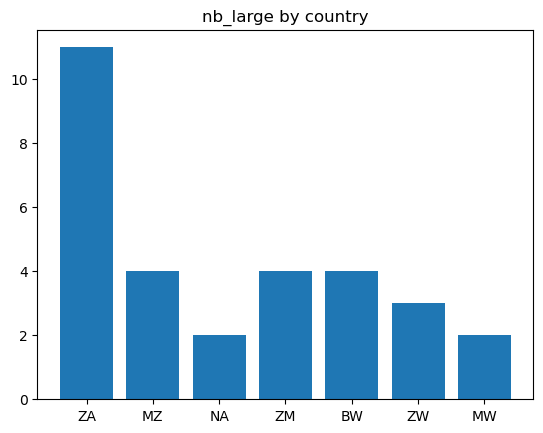

In [41]:
import matplotlib.pyplot as plt

#  Nombre de grands aéroports par pays
colonne_a_visualiser = "nb_large"

fig, ax = plt.subplots()
ax.bar(synthese["country"], synthese[colonne_a_visualiser])
ax.set_title(f"{colonne_a_visualiser} by country")
plt.show()


## 5- Choix du graphique

D'après le cours, le *bar chart horizontal* est recommandé pour comparer une quantité entre catégories (pays). Il permet à l'œil de comparer des longueurs alignées sur une base commune, ce qui est la tâche perceptive la plus précise pour ce type de comparaison. L'orientation horizontale a un avantage supplémentaire ici : les noms de pays (courts dans notre cas, mais le principe vaut en général) restent lisibles à plat, sans rotation ni troncature.

**Justification du choix**
*Pourquoi un pie chart, un donut chart ou un graphique 3D seraient de mauvais choix ici ?*

- **Pie / donut chart** : l'œil humain compare mal des angles ou des aires de façon précise, surtout quand les valeurs sont proches (ex. Mozambique 4, Zambie 4, Botswana 4 grands aéroports), un bar chart rend ces égalités immédiatement visibles, un camembert les noierait dans des tranches visuellement similaires. De plus, un pays (l'Afrique du Sud) représente une part dominante du total : sur un camembert cela écraserait visuellement toutes les autres tranches, alors que mon message porte justement sur les pays les plus faibles, pas sur le plus gros contributeur.

- **Graphique** : la perspective déforme la perception des hauteurs/profondeurs relatives (une barre à l'arrière paraît plus petite qu'une barre identique à l'avant), ce qui introduit un biais visuel sans aucun gain d'information, l'effet 3D est purement décoratif et nuit à la lecture précise des valeurs, exactement ce qu'on veut éviter pour un comité qui doit comparer des chiffres pour décider.


## 6- Decluttering pas à pas


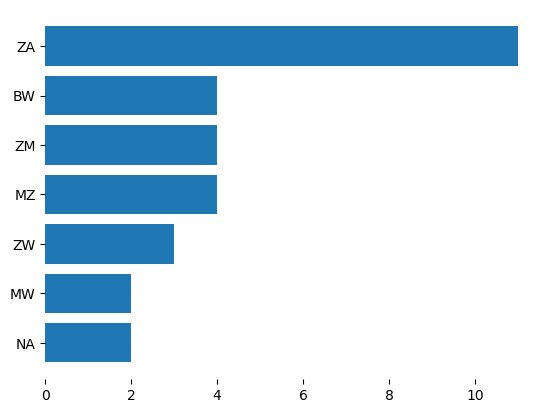

In [42]:
# Étape 1 — Passage en barres horizontales et suppression de la bordure du graphique

synthese_sorted = synthese.sort_values(colonne_a_visualiser)

fig, ax = plt.subplots()
ax.barh(synthese_sorted["country"], synthese_sorted[colonne_a_visualiser])

# Suppression des 4 bordures (spines) du graphique
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)

plt.show()


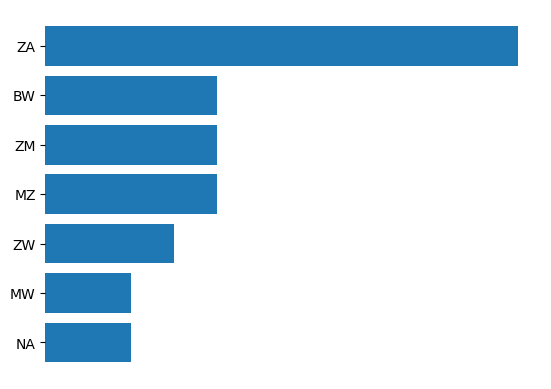

In [13]:
# Étape 2 — Nettoyer les labels d'axes 

fig, ax = plt.subplots()
ax.barh(synthese_sorted["country"], synthese_sorted[colonne_a_visualiser])
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)

# Suppression des graduations et du label de l'axe x : les valeurs seront labellisées
# directement sur les barres à l'étape suivante, l'axe x n'apporte donc plus rien.
ax.tick_params(axis="x", length=0)
ax.set_xticklabels([])
ax.set_xlabel("")

plt.show()


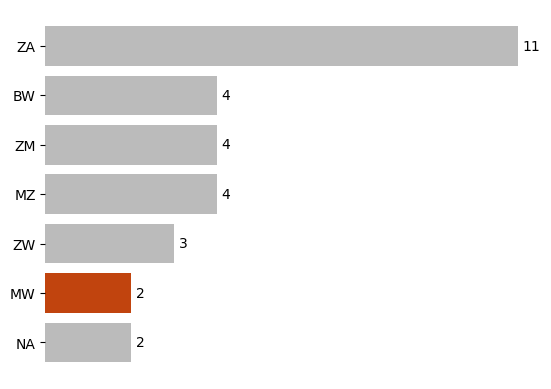

In [43]:
# Étape 3- Labellisation directe des données + couleur intentionnelle 
# Pays mis en évidence : le Malawi, cible de la recommandation d'investissement
pays_a_mettre_en_evidence = "MW"

couleurs = [
    "#C1440E" if pays == pays_a_mettre_en_evidence else "#BBBBBB"
    for pays in synthese_sorted["country"]
]

fig, ax = plt.subplots()
barres = ax.barh(synthese_sorted["country"], synthese_sorted[colonne_a_visualiser], color=couleurs)
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.set_xticklabels([])
ax.set_xlabel("")

# Valeur directement au bout de chaque barre (label direct, pas de légende)
for barre, valeur in zip(barres, synthese_sorted[colonne_a_visualiser]):
    ax.text(barre.get_width() + 0.1, barre.get_y() + barre.get_height() / 2,
            str(int(valeur)), va="center", fontsize=10)

plt.show()


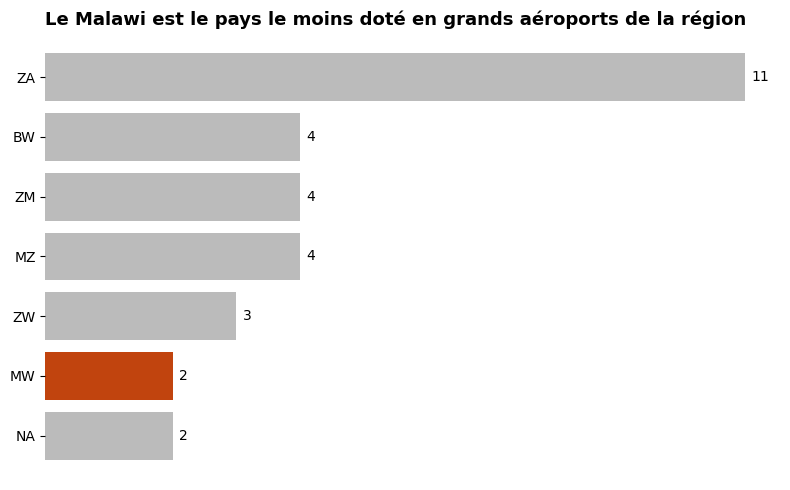

In [44]:
# Étape 4 - Version finale : titre déclaratif

titre_declaratif = "Le Malawi est le pays le moins doté en grands aéroports de la région"

fig, ax = plt.subplots(figsize=(8, 5))
barres = ax.barh(synthese_sorted["country"], synthese_sorted[colonne_a_visualiser], color=couleurs)
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.set_xticklabels([])
ax.set_xlabel("")
for barre, valeur in zip(barres, synthese_sorted[colonne_a_visualiser]):
    ax.text(barre.get_width() + 0.1, barre.get_y() + barre.get_height() / 2,
            str(int(valeur)), va="center", fontsize=10)

ax.set_title(titre_declaratif, fontsize=13, fontweight="bold", loc="left")
plt.tight_layout()
plt.savefig("graphique_final.png", dpi=150, bbox_inches="tight")
plt.show()


## Conclusion

Au comité d'investissement régional : sur les 7 pays de l'échantillon analysé, le **Malawi** dispose de l'infrastructure aéroportuaire de premier rang la plus faible, avec seulement 2 grands aéroports, à égalité avec la Namibie, mais avec un réseau secondaire bien moins développé (2 aéroports en service régulier contre 11 pour la Namibie). Nous recommandons de prioriser l'instruction d'un dossier d'investissement aéroportuaire pour le Malawi plutôt que pour les autres pays de la région, ce pays présentant le déficit d'infrastructure le plus clair et le plus actionnable de l'échantillon.
